In [47]:
todos = glob.glob(os.path.join(pasta, "*.tif"))
for i, arq in enumerate(sorted(todos)):
    print(f"{i+1:02d} ➜ {os.path.basename(arq)}")


01 ➜ Albedo_Max_2001.tif
02 ➜ Albedo_Mean_2001.tif
03 ➜ Albedo_Mean_2006.tif
04 ➜ Albedo_Mean_2011.tif
05 ➜ Albedo_Mean_2016.tif
06 ➜ Albedo_Mean_2021.tif
07 ➜ Albedo_Min_2001.tif
08 ➜ BAEI_Max_2001.tif
09 ➜ BAEI_Mean_2001.tif
10 ➜ BAEI_Mean_2006.tif
11 ➜ BAEI_Mean_2011.tif
12 ➜ BAEI_Mean_2016.tif
13 ➜ EVI_Mean_2006.tif
14 ➜ EVI_Mean_2011.tif
15 ➜ EVI_Mean_2016.tif
16 ➜ EVI_Mean_2021.tif
17 ➜ GCI_Max_2001.tif
18 ➜ GCI_Mean_2001.tif
19 ➜ GCI_Mean_2006.tif
20 ➜ GCI_Mean_2011.tif
21 ➜ GCI_Mean_2016.tif
22 ➜ GCI_Mean_2021.tif
23 ➜ GCI_Min_2001.tif
24 ➜ LST_Max_2001.tif
25 ➜ LST_Mean_2001.tif
26 ➜ LST_Mean_2006.tif
27 ➜ LST_Mean_2011.tif
28 ➜ LST_Mean_2016.tif
29 ➜ LST_Mean_2021.tif
30 ➜ LST_Min_2001.tif
31 ➜ NDBI_Max_2001.tif
32 ➜ NDBI_Mean_2001.tif
33 ➜ NDBI_Mean_2006.tif
34 ➜ NDBI_Mean_2011.tif
35 ➜ NDBI_Mean_2016.tif
36 ➜ NDBI_Mean_2021.tif
37 ➜ NDBI_Min_2001.tif
38 ➜ NDMI_Mean_2011.tif
39 ➜ NDMI_Mean_2016.tif
40 ➜ NDMI_Mean_2021.tif
41 ➜ NDVI_Max_2001.tif
42 ➜ NDVI_Mean_2006.tif
43 ➜ N

In [53]:
import os
import glob
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from sklearn.decomposition import PCA
import pandas as pd

# === CONFIGURAÇÕES ===
pasta = "C:/Python/TESE/GEE_Export_Mozambique"
saida_base_global = "C:/Python/TESE/ANALISE_ANUAL"
anos = ["2001", "2006", "2011", "2016", "2021"]

# === IDENTIFICA ARQUIVOS DE TOPOGRAFIA (ENTRAM SEMPRE) ===
arquivos_topo = [
    os.path.join(pasta, f)
    for f in os.listdir(pasta)
    if f.lower().startswith("topografia") and f.endswith(".tif")
]

# === FUNÇÃO PARA REPROJETAR CADA IMAGEM ===
def padronizar(imagem, shape_ref, transform_ref, crs_ref):
    with rasterio.open(imagem) as src:
        array = np.zeros((src.count, *shape_ref), dtype=np.float32)
        for i in range(src.count):
            reproject(
                source=src.read(i + 1),
                destination=array[i],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform_ref,
                dst_crs=crs_ref,
                resampling=Resampling.bilinear,
            )
        return array

# === LOOP POR ANO ===
for ano in anos:
    print(f"\n🗓️ Iniciando PCA para o ano {ano}...")

    # === Arquivos do ano ===
    arquivos_ano = [
        os.path.join(pasta, f)
        for f in os.listdir(pasta)
        if f.endswith(".tif") and "_Mean" in f and ano in f
    ] + arquivos_topo  # inclui topografia estática

    if not arquivos_ano:
        print(f"⚠️ Nenhum arquivo encontrado para {ano}")
        continue

    print(f"📂 {len(arquivos_ano)} arquivos serão empilhados para {ano}")

    # === Referência espacial ===
    with rasterio.open(arquivos_ano[0]) as ref:
        ref_shape = ref.shape
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_meta = ref.meta.copy()

    # === Empilhamento ===
    nomes_bandas = []
    pilhas = []

    for arq in arquivos_ano:
        with rasterio.open(arq) as src:
            for i in range(src.count):
                nome_base = os.path.basename(arq).replace(".tif", "")
                nomes_bandas.append(f"{nome_base}_B{i+1}")
        pilhas.append(padronizar(arq, ref_shape, ref_transform, ref_crs))

    empilhado = np.concatenate(pilhas, axis=0)
    n_bandas, n_linhas, n_colunas = empilhado.shape
    print(f"📊 Empilhado: {n_bandas} bandas | {n_linhas} x {n_colunas} pixels")

    # === PCA ===
    dados_2d = empilhado.reshape(n_bandas, -1).T
    valido = ~np.any(np.isnan(dados_2d), axis=1)
    dados_validos = dados_2d[valido]

    pca_temp = PCA().fit(dados_validos)
    var_acumulada = np.cumsum(pca_temp.explained_variance_ratio_)
    n_componentes = np.argmax(var_acumulada >= 0.95) + 1

    print(f"📈 {n_componentes} componentes ≥ 95% da variância explicada")

    pca = PCA(n_components=n_componentes)
    pca_resultado = pca.fit_transform(dados_validos)

    pc_imagens = np.full((n_componentes, n_linhas * n_colunas), np.nan, dtype=np.float32)
    pc_imagens[:, valido] = pca_resultado.T
    pc_imagens = pc_imagens.reshape((n_componentes, n_linhas, n_colunas))

    # === EXPORTA ===
    ref_meta.update({"count": n_componentes, "dtype": "float32", "compress": "lzw"})
    saida_base = os.path.join(saida_base_global, ano)
    os.makedirs(saida_base, exist_ok=True)

    with rasterio.open(os.path.join(saida_base, f"PCs_{ano}.tif"), "w", **ref_meta) as dst:
        dst.write(pc_imagens.astype(np.float32))

    # === SALVA PESOS ===
    df_pesos = pd.DataFrame(pca.components_, columns=nomes_bandas)
    df_pesos.index = [f"PC{i+1}" for i in range(n_componentes)]
    df_pesos.to_csv(os.path.join(saida_base, f"pesos_{ano}.csv"))

    # === VARIÂNCIA EXPLICADA ===
    df_var = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(n_componentes)],
        "Variancia": pca.explained_variance_ratio_,
        "Variancia_Acumulada": var_acumulada[:n_componentes]
    })
    df_var.to_csv(os.path.join(saida_base, f"variancia_{ano}.csv"), index=False)

    # === NOMES DAS BANDAS ===
    with open(os.path.join(saida_base, f"nomes_bandas_{ano}.txt"), "w") as f:
        for nome in nomes_bandas:
            f.write(f"{nome}\n")

    print(f"✅ PCA para {ano} finalizada. Resultados salvos em {saida_base}")



🗓️ Iniciando PCA para o ano 2001...
📂 10 arquivos serão empilhados para 2001
📊 Empilhado: 14 bandas | 3651 x 2366 pixels
📈 1 componentes ≥ 95% da variância explicada
✅ PCA para 2001 finalizada. Resultados salvos em C:/Python/TESE/ANALISE_ANUAL\2001

🗓️ Iniciando PCA para o ano 2006...
📂 13 arquivos serão empilhados para 2006
📊 Empilhado: 17 bandas | 3651 x 2366 pixels
📈 1 componentes ≥ 95% da variância explicada
✅ PCA para 2006 finalizada. Resultados salvos em C:/Python/TESE/ANALISE_ANUAL\2006

🗓️ Iniciando PCA para o ano 2011...
📂 12 arquivos serão empilhados para 2011
📊 Empilhado: 16 bandas | 3651 x 2366 pixels
📈 1 componentes ≥ 95% da variância explicada
✅ PCA para 2011 finalizada. Resultados salvos em C:/Python/TESE/ANALISE_ANUAL\2011

🗓️ Iniciando PCA para o ano 2016...
📂 13 arquivos serão empilhados para 2016
📊 Empilhado: 17 bandas | 3651 x 2366 pixels
📈 1 componentes ≥ 95% da variância explicada
✅ PCA para 2016 finalizada. Resultados salvos em C:/Python/TESE/ANALISE_ANUAL\2016


In [54]:
import rasterio
import numpy as np
import os

# Caminhos
anos = ["2001", "2006", "2011", "2016"]
entrada_base = "C:/Python/TESE/MCD12Q1_LC_Type1_{}.tif"
saida_base = "C:/Python/TESE/MCD12Q1_Reclassificado_{}.tif"

# Mapeamento de classes MODIS → Simplificadas
reclass_map = {
    0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1,
    6: 2,
    7: 3, 8: 3,
    9: 4, 10: 4,
    11: 5,
    12: 6,
    13: 4, 14: 4, 15: 4, 16: 4
}

for ano in anos:
    entrada = entrada_base.format(ano)
    saida = saida_base.format(ano)
    
    with rasterio.open(entrada) as src:
        imagem = src.read(1)
        perfil = src.profile

    reclassificada = np.copy(imagem)
    for old_val, new_val in reclass_map.items():
        reclassificada[imagem == old_val] = new_val

    perfil.update(dtype="int16", compress="lzw")

    with rasterio.open(saida, "w", **perfil) as dst:
        dst.write(reclassificada.astype("int16"), 1)

    print(f"✅ Reclassificado {ano} salvo em: {saida}")


✅ Reclassificado 2001 salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_2001.tif
✅ Reclassificado 2006 salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_2006.tif
✅ Reclassificado 2011 salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_2011.tif
✅ Reclassificado 2016 salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_2016.tif


In [56]:
import rasterio
from rasterio.warp import reproject, Resampling
import os
import numpy as np

# === CONFIGURAÇÕES ===
anos = ["2001", "2006", "2011", "2016"]
reclass_base = "C:/Python/TESE/MCD12Q1_Reclassificado_{}.tif"
saida_base = "C:/Python/TESE/MCD12Q1_Reclassificado_RESAMPLADO_{}.tif"

# === CAMINHO DA IMAGEM DE REFERÊNCIA (ex: um índice MODIS ou PC)
imagem_referencia = "C:/Python/TESE/GEE_Export_Mozambique/NDVI_Mean_2006.tif"

# === LÊ PERFIL DE REFERÊNCIA ===
with rasterio.open(imagem_referencia) as ref:
    shape_ref = ref.shape
    transform_ref = ref.transform
    crs_ref = ref.crs
    profile_ref = ref.profile.copy()

# === LOOP PARA REPROJETAR ===
for ano in anos:
    entrada = reclass_base.format(ano)
    saida = saida_base.format(ano)

    with rasterio.open(entrada) as src:
        data_src = src.read(1)
        transform_src = src.transform
        crs_src = src.crs

        # Array de destino (com mesmo shape da imagem de referência)
        destino = np.empty(shape_ref, dtype=np.int16)

        # Reprojetar com vizinho mais próximo (preserva classes)
        reproject(
            source=data_src,
            destination=destino,
            src_transform=transform_src,
            src_crs=crs_src,
            dst_transform=transform_ref,
            dst_crs=crs_ref,
            resampling=Resampling.nearest
        )

    # Atualiza metadados
    profile_ref.update({
        "dtype": "int16",
        "count": 1,
        "compress": "lzw"
    })

    # Salva imagem reamostrada
    with rasterio.open(saida, "w", **profile_ref) as dst:
        dst.write(destino, 1)

    print(f"✅ {ano} reamostrado e salvo em: {saida}")


✅ 2001 reamostrado e salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_RESAMPLADO_2001.tif
✅ 2006 reamostrado e salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_RESAMPLADO_2006.tif
✅ 2011 reamostrado e salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_RESAMPLADO_2011.tif
✅ 2016 reamostrado e salvo em: C:/Python/TESE/MCD12Q1_Reclassificado_RESAMPLADO_2016.tif


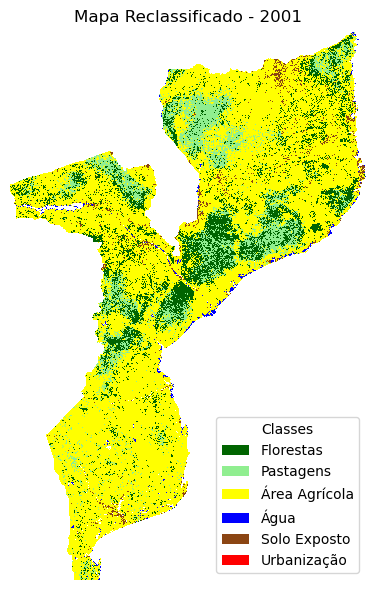

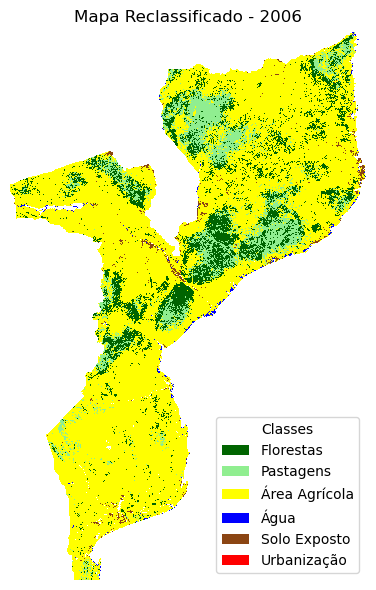

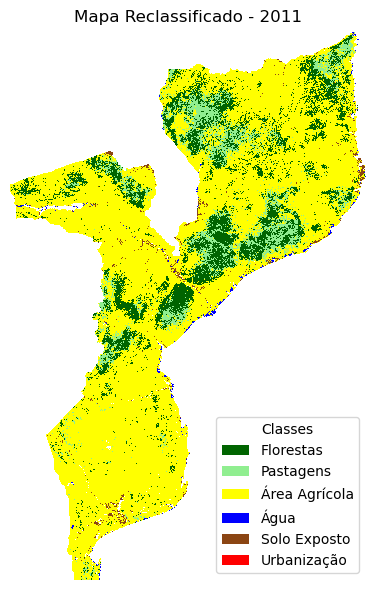

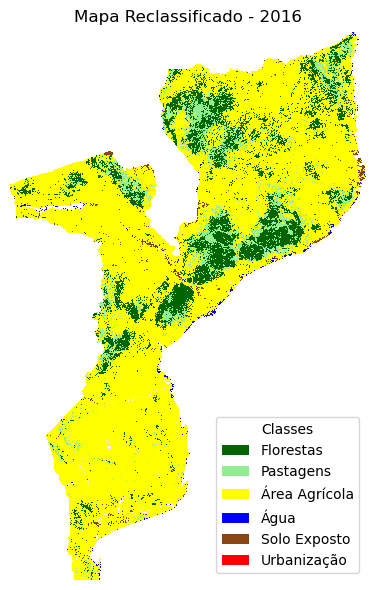

In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

# === CONFIGURAÇÕES ===
anos = ["2001", "2006", "2011", "2016"]
caminho_base = "C:/Python/TESE/MCD12Q1_Reclassificado_RESAMPLADO_{}.tif"

# === NOVAS CLASSES E CORES ===
classes = {
    1: ('Florestas', '#006400'),        # verde escuro
    2: ('Pastagens', '#90EE90'),        # verde claro
    3: ('Área Agrícola', '#FFFF00'),    # amarelo
    4: ('Água', '#0000FF'),             # azul
    5: ('Solo Exposto', '#8B4513'),     # castanho-marrom
    6: ('Urbanização', '#FF0000')       # vermelho
}

# === FUNÇÃO PARA PLOTAR UM MAPA ===
def plotar_mapa(data, ano, cmap, legend_labels):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, interpolation='nearest', vmin=1, vmax=6)
    plt.title(f"Mapa Reclassificado - {ano}")
    plt.axis('off')

    # Cria legenda personalizada
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=label) for label, color in legend_labels.values()]
    plt.legend(handles=legend_elements, loc='lower right', title="Classes")

    plt.tight_layout()
    plt.show()

# === LOOP PARA CADA ANO ===
for ano in anos:
    caminho = caminho_base.format(ano)

    with rasterio.open(caminho) as src:
        data = src.read(1)

        # Cria colormap personalizado
        from matplotlib.colors import ListedColormap
        cores = [classes[val][1] for val in sorted(classes.keys())]
        cmap = ListedColormap(cores)

        # Garante que apenas valores válidos estejam no mapa
        data = np.where(np.isin(data, list(classes.keys())), data, np.nan)

        # Ajusta valores para corresponder à colormap (começando de 0 no array de cores)
        data_mapped = np.vectorize(lambda x: list(classes.keys()).index(x) if x in classes else np.nan)(data)

        # Plota
        plotar_mapa(data_mapped, ano, cmap, classes)
